# Worksheet 6: Image Classification with CNN and Transfer Learning


In [1]:
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.metrics import classification_report

SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Task 1: Data understanding and visualizations

In [2]:
# Locate dataset path
search_roots = [Path.cwd(), Path.cwd().parent]
dataset_candidates = []

for root in search_roots:
    dataset_candidates = sorted(root.glob("**/FruitinAmazon/FruitinAmazon"))
    if dataset_candidates:
        break

if not dataset_candidates:
    raise FileNotFoundError("Could not find 'FruitinAmazon/FruitinAmazon' in this project.")

dataset_root = dataset_candidates[0]
train_dir = dataset_root / "train"
test_dir = dataset_root / "test"

print("Dataset root:", dataset_root)
print("Train directory:", train_dir)
print("Test directory:", test_dir)

class_dirs = sorted([d for d in train_dir.iterdir() if d.is_dir()])
class_names = [d.name for d in class_dirs]
print("Classes:", class_names)

Dataset root: d:\college\sem6\aml\Week 5 - Introduction to CNN-20260402T065755Z-1-001\ Week 5 - Introduction to CNN\FruitinAmazon\FruitinAmazon
Train directory: d:\college\sem6\aml\Week 5 - Introduction to CNN-20260402T065755Z-1-001\ Week 5 - Introduction to CNN\FruitinAmazon\FruitinAmazon\train
Test directory: d:\college\sem6\aml\Week 5 - Introduction to CNN-20260402T065755Z-1-001\ Week 5 - Introduction to CNN\FruitinAmazon\FruitinAmazon\test
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [3]:
# Check corrupted images and class balance
corrupted_images = []
class_counts = {}

for class_dir in class_dirs:
    valid_count = 0
    for image_path in class_dir.iterdir():
        if not image_path.is_file():
            continue
        if not image_path.suffix.lower() in {".png", ".jpg", ".jpeg"}:
            continue
        try:
            with Image.open(image_path) as img:
                img.verify()
            valid_count += 1
        except (IOError, UnidentifiedImageError, SyntaxError):
            corrupted_images.append(str(image_path))
            image_path.unlink(missing_ok=True)
            print(f"Removed corrupted image: {image_path}")

    class_counts[class_dir.name] = valid_count

if not corrupted_images:
    print("No corrupted images found.")

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>20}")
print("=" * 45)
for name, count in class_counts.items():
    print(f"{name:<25}{count:>20}")
print("=" * 45)

No corrupted images found.

Class Distribution:
Class Name                  Valid Image Count
acai                                       15
cupuacu                                    15
graviola                                   15
guarana                                    15
pupunha                                    15
tucuma                                     15


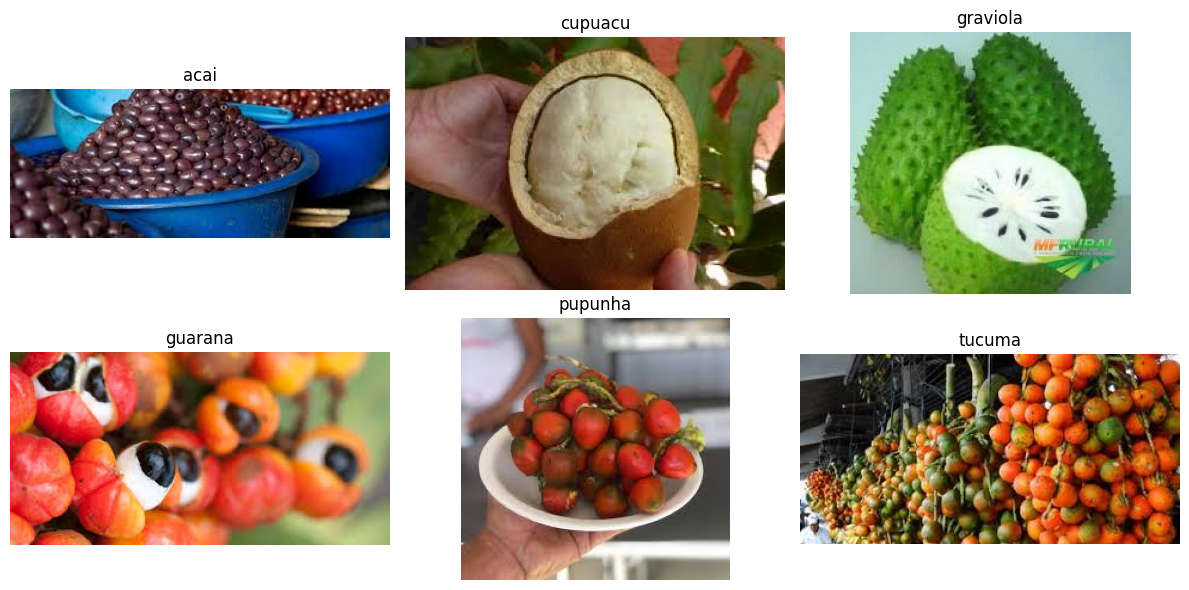

In [4]:
# Visualize one random image per class
selected_images = []
selected_labels = []

for class_dir in class_dirs:
    images = [p for p in class_dir.iterdir() if p.is_file() and p.suffix.lower() in {".png", ".jpg", ".jpeg"}]
    if images:
        selected = random.choice(images)
        selected_images.append(selected)
        selected_labels.append(class_dir.name)

num_classes = len(selected_images)
rows = 2
cols = int(np.ceil(num_classes / rows))

plt.figure(figsize=(4 * cols, 6))
for i, img_path in enumerate(selected_images):
    plt.subplot(rows, cols, i + 1)
    img = Image.open(img_path).convert("RGB")
    plt.imshow(img)
    plt.title(selected_labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Task 2: Data generation and preprocessing

In [5]:
# Create train/validation/test datasets
img_height, img_width = 128, 128
batch_size = 16

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=SEED,
    image_size=(img_height, img_width),
    batch_size=batch_size,
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    seed=SEED,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
)

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Class names:", class_names)
print("Number of classes:", num_classes)

for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6
Images shape: (16, 128, 128, 3)
Labels shape: (16,)


### Data augmentation preview

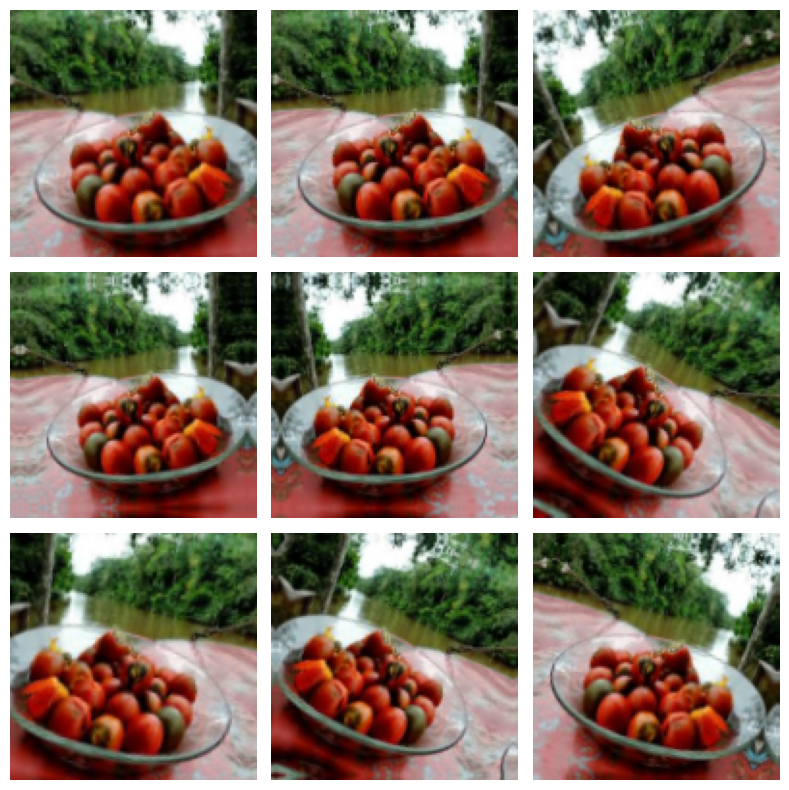

In [6]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

plt.figure(figsize=(8, 8))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images, training=True)
        plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")
plt.tight_layout()
plt.show()

## Task 3: Improved CNN from scratch (augmentation + BatchNormalization + Dropout)

In [7]:
scratch_model = keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    data_augmentation,
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, (3, 3), padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax"),
], name="scratch_cnn_bn_dropout")

scratch_model.summary()

Model: "scratch_cnn_bn_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,54

 Total params: 8,485,094 (32.37 MB)

 Trainable params: 8,484,134 (32.36 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
scratch_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

scratch_checkpoint = ModelCheckpoint(
    "scratch_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1,
)

scratch_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)

scratch_history = scratch_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    callbacks=[scratch_checkpoint, scratch_early_stop],
    verbose=1,
)

Epoch 1/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 217ms/step - accuracy: 0.3056 - loss: 1.9760 - val_accuracy: 0.1667 - val_loss: 1.8436
Epoch 2/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.6250 - loss: 1.0054 - val_accuracy: 0.2222 - val_loss: 1.8113
Epoch 3/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - accuracy: 0.5833 - loss: 1.0628 - val_accuracy: 0.2222 - val_loss: 1.7724
Epoch 4/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.7083 - loss: 0.7295 - val_accuracy: 0.2222 - val_loss: 1.7378
Epoch 5/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.6944 - loss: 0.7272 - val_accuracy: 0.2222 - val_loss: 1.7038
Epoch 6/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.7500 - loss: 0.6186 - val_accuracy: 0.2222 - val_loss: 1.7415
Epoch 7/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.8194 - loss: 0.5412 - val_accuracy: 0.2222 - val_loss: 1.9339
Epoch 8/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.8056 - loss: 0.4941 - val_accuracy: 0.2222 - val_loss:

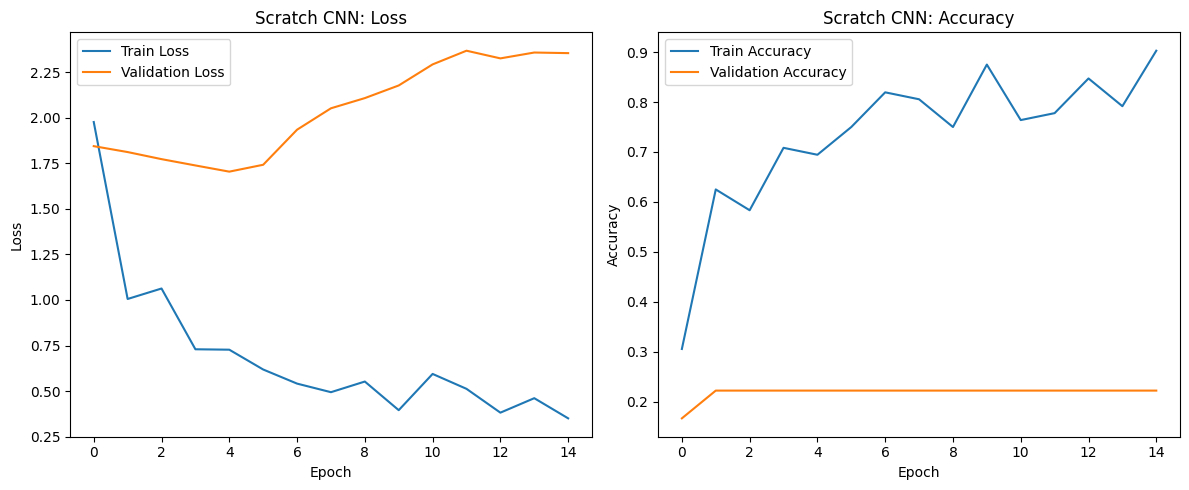

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3000 - loss: 1.7474
Scratch CNN Test Loss: 1.7474
Scratch CNN Test Accuracy: 0.3000


In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(scratch_history.history["loss"], label="Train Loss")
plt.plot(scratch_history.history["val_loss"], label="Validation Loss")
plt.title("Scratch CNN: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(scratch_history.history["accuracy"], label="Train Accuracy")
plt.plot(scratch_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Scratch CNN: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

scratch_test_loss, scratch_test_acc = scratch_model.evaluate(test_ds, verbose=1)
print(f"Scratch CNN Test Loss: {scratch_test_loss:.4f}")
print(f"Scratch CNN Test Accuracy: {scratch_test_acc:.4f}")

In [ ]:
# Save and reload the scratch model
scratch_model.save("scratch_cnn_bn_dropout.h5")
print("Saved model: scratch_cnn_bn_dropout.h5")

scratch_loaded_model = keras.models.load_model("scratch_cnn_bn_dropout.h5")
loaded_test_loss, loaded_test_acc = scratch_loaded_model.evaluate(test_ds, verbose=1)
print(f"Reloaded Scratch Model Test Loss: {loaded_test_loss:.4f}")
print(f"Reloaded Scratch Model Test Accuracy: {loaded_test_acc:.4f}")

In [10]:
# Inference output and classification report on test set
test_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)

scratch_test_probs = scratch_loaded_model.predict(test_ds)
scratch_test_pred = np.argmax(scratch_test_probs, axis=1)

sample_pred_names = [class_names[i] for i in scratch_test_pred[:15]]
print("Sample predicted class labels (scratch model):")
print(sample_pred_names)

print("\nClassification Report (scratch model):\n")
print(classification_report(test_true, scratch_test_pred, target_names=class_names, zero_division=0))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Sample predicted class labels (scratch model):
['cupuacu', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu']

Classification Report (scratch model):

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       0.22      1.00      0.36         4
    graviola       0.00      0.00      0.00         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.00      0.00      0.00         4
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.22        18
   macro avg       0.04      0.17      0.06        18
weighted avg       0.05      0.22      0.08        18



## Task 4: Transfer learning with frozen VGG16

In [11]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(img_height, img_width, 3),
)
base_model.trainable = False

transfer_inputs = keras.Input(shape=(img_height, img_width, 3))
x = data_augmentation(transfer_inputs)
x = layers.Lambda(preprocess_input)(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
transfer_outputs = layers.Dense(num_classes, activation="softmax")(x)

transfer_model = keras.Model(transfer_inputs, transfer_outputs, name="vgg16_frozen_transfer")

transfer_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

transfer_model.summary()

Model: "vgg16_frozen_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 132,870 (519.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [12]:
transfer_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1,
)

transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[transfer_early_stop],
    verbose=1,
)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 447ms/step - accuracy: 0.2500 - loss: 9.4714 - val_accuracy: 0.3333 - val_loss: 7.4394
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 362ms/step - accuracy: 0.5972 - loss: 4.0152 - val_accuracy: 0.3889 - val_loss: 5.3413
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 360ms/step - accuracy: 0.7778 - loss: 1.7105 - val_accuracy: 0.5000 - val_loss: 4.0658
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 362ms/step - accuracy: 0.8750 - loss: 0.6417 - val_accuracy: 0.5556 - val_loss: 4.1452
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 356ms/step - accuracy: 0.9444 - loss: 0.3721 - val_accuracy: 0.5000 - val_loss: 4.0346
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 350ms/step - accuracy: 0.9167 - loss: 0.4668 - val_accuracy: 0.5556 - val_loss: 4.3333
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 356ms/step - accuracy: 0.9444 - loss: 0.4293 - val_accuracy: 0.5556 - val_loss: 4.3677
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 352ms/step - accuracy: 0.9722 - loss: 0.2713 - val_accuracy: 0.5556 - val_loss:

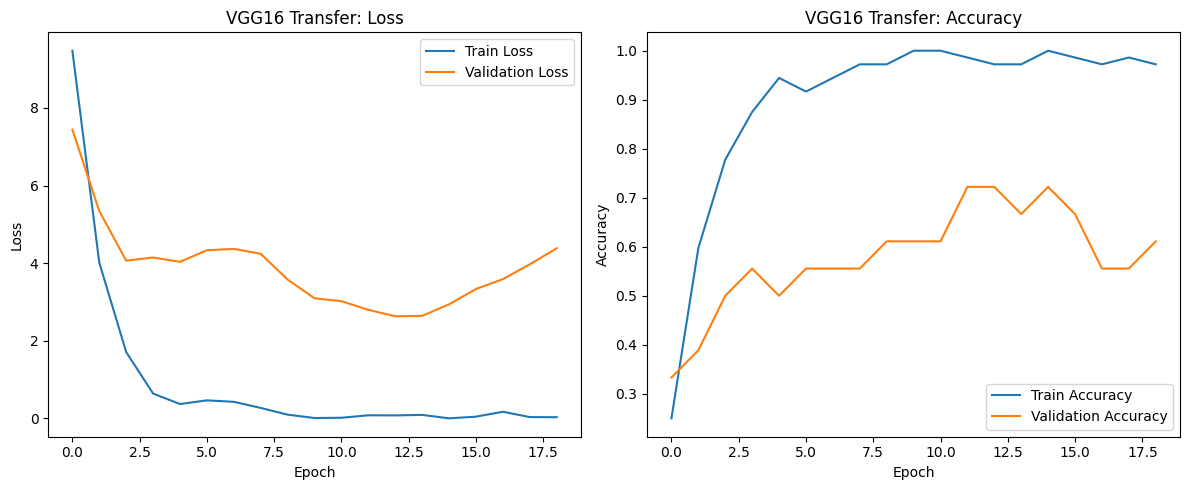

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 270ms/step - accuracy: 0.7667 - loss: 2.7117
Transfer Model Test Loss: 2.7117
Transfer Model Test Accuracy: 0.7667
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 345ms/step

Sample predicted class labels (transfer model):
['tucuma', 'tucuma', 'cupuacu', 'tucuma', 'cupuacu', 'guarana', 'tucuma', 'tucuma', 'guarana', 'acai', 'acai', 'pupunha', 'tucuma', 'acai', 'tucuma']

Classification Report (transfer model):

              precision    recall  f1-score   support

        acai       0.67      0.67      0.67         3
     cupuacu       1.00      0.75      0.86         4
    graviola       1.00      1.00      1.00         1
     guarana       0.50      1.00      0.67         1
     pupunha       1.00      0.50      0.67         4
      tucuma       0.57      0.80      0.67         5

    accuracy                           0.72        18
   macro avg       0.79      0.79      0.75        18
weighted avg       0.80      0.72      0.73        18


Performance comparison (test accu

In [13]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(transfer_history.history["loss"], label="Train Loss")
plt.plot(transfer_history.history["val_loss"], label="Validation Loss")
plt.title("VGG16 Transfer: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(transfer_history.history["accuracy"], label="Train Accuracy")
plt.plot(transfer_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("VGG16 Transfer: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

transfer_test_loss, transfer_test_acc = transfer_model.evaluate(test_ds, verbose=1)
print(f"Transfer Model Test Loss: {transfer_test_loss:.4f}")
print(f"Transfer Model Test Accuracy: {transfer_test_acc:.4f}")

val_true = np.concatenate([labels.numpy() for _, labels in val_ds], axis=0)
transfer_val_probs = transfer_model.predict(val_ds)
transfer_val_pred = np.argmax(transfer_val_probs, axis=1)

sample_transfer_pred_names = [class_names[i] for i in transfer_val_pred[:15]]
print("\nSample predicted class labels (transfer model):")
print(sample_transfer_pred_names)

print("\nClassification Report (transfer model):\n")
print(classification_report(val_true, transfer_val_pred, target_names=class_names, zero_division=0))

print("\nPerformance comparison (test accuracy):")
print(f"Scratch CNN:  {scratch_test_acc:.4f}")
print(f"VGG16 Transfer: {transfer_test_acc:.4f}")

if transfer_test_acc > scratch_test_acc:
    print("Transfer learning improved the test accuracy compared to training from scratch.")
elif transfer_test_acc < scratch_test_acc:
    print("Transfer learning did not improve test accuracy in this run.")
else:
    print("Both models achieved the same test accuracy in this run.")